# Challenge 3

In [1]:
# Pick one stock from the top 5 winning stock
# Create a SMA (Long/Flat strategy)
# Create a bias strategy
# Compare returns and drawdowns

In [2]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
#import Palentir's prices
pltr = yf.download("PLTR", auto_adjust= True, period = "max")
pltr

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,PLTR,PLTR,PLTR,PLTR,PLTR
Date,,,,,
2020-09-30,9.500000,11.410000,9.110000,10.000000,338584400
2020-10-01,9.460000,10.100000,9.230000,9.690000,124297600
2020-10-02,9.200000,9.280000,8.940000,9.060000,55018300
2020-10-05,9.030000,9.490000,8.920000,9.430000,36316900
2020-10-06,9.900000,10.180000,8.900000,9.040000,90864000
...,...,...,...,...,...
2026-03-23,160.839996,161.080002,153.240005,153.240005,57507100
2026-03-24,154.779999,162.399994,151.639999,160.070007,56155700


In [4]:
#we want only the closing prices
data = pltr["Close"].copy()
data

Ticker,PLTR
Date,
2020-09-30,9.500000
2020-10-01,9.460000
2020-10-02,9.200000
2020-10-05,9.030000
2020-10-06,9.900000
...,...
2026-03-23,160.839996
2026-03-24,154.779999
2026-03-25,154.960007


In [5]:
#calculate a column for daily return using log
data.columns = ["Close"]
data

,Close
Date,
2020-09-30,9.500000
2020-10-01,9.460000
2020-10-02,9.200000
2020-10-05,9.030000
2020-10-06,9.900000
...,...
2026-03-23,160.839996
2026-03-24,154.779999
2026-03-25,154.960007


In [6]:
#create a column to store sma data 50 and 20
sma_s = 50
sma_l = 200
data["sma_s"] = data.Close.rolling(sma_s).mean()
data["sma_l"] = data.Close.rolling(sma_l).mean()
data

,Close,sma_s,sma_l
Date,,,
2020-09-30,9.500000,NaN,NaN
2020-10-01,9.460000,NaN,NaN
2020-10-02,9.200000,NaN,NaN
2020-10-05,9.030000,NaN,NaN
2020-10-06,9.900000,NaN,NaN
...,...,...,...
2026-03-23,160.839996,151.2488,163.583575
2026-03-24,154.779999,150.7946,163.757925
2026-03-25,154.960007,150.3056,163.894125


<Axes: title={'center': 'PLTR - SMA50 | SMA200'}, xlabel='Date'>

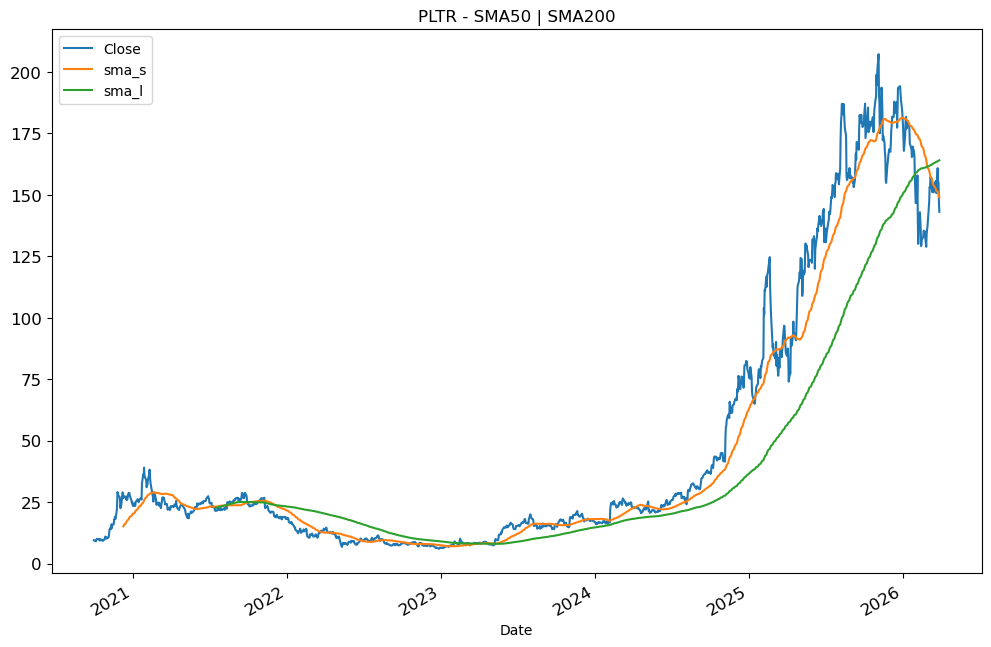

In [7]:
data.plot(figsize = (12,8), title = "PLTR - SMA{} | SMA{}".format(sma_s,sma_l), fontsize = 12)

In [8]:
data.dropna(inplace = True)

In [9]:
data

,Close,sma_s,sma_l
Date,,,
2021-07-16,21.370001,23.1150,22.686050
2021-07-19,21.540001,23.1440,22.746250
2021-07-20,22.180000,23.1926,22.809850
2021-07-21,22.520000,23.2736,22.876450
2021-07-22,22.070000,23.3108,22.941650
...,...,...,...
2026-03-23,160.839996,151.2488,163.583575
2026-03-24,154.779999,150.7946,163.757925
2026-03-25,154.960007,150.3056,163.894125


In [11]:
data["position"] = np.where(data["sma_s"]>data["sma_l"],1,0)
data

,Close,sma_s,sma_l,position
Date,,,,
2021-07-16,21.370001,23.1150,22.686050,1
2021-07-19,21.540001,23.1440,22.746250,1
2021-07-20,22.180000,23.1926,22.809850,1
2021-07-21,22.520000,23.2736,22.876450,1
2021-07-22,22.070000,23.3108,22.941650,1
...,...,...,...,...
2026-03-23,160.839996,151.2488,163.583575,0
2026-03-24,154.779999,150.7946,163.757925,0
2026-03-25,154.960007,150.3056,163.894125,0


In [12]:
#calculate daily returns for buy&hold, sma (flat strategy)
data["d_returnsb&h"] = np.log(data.Close.div(data.Close.shift(1)))

In [13]:
data

,Close,sma_s,sma_l,position,d_returnsb&h
Date,,,,,
2021-07-16,21.370001,23.1150,22.686050,1,NaN
2021-07-19,21.540001,23.1440,22.746250,1,0.007924
2021-07-20,22.180000,23.1926,22.809850,1,0.029279
2021-07-21,22.520000,23.2736,22.876450,1,0.015213
2021-07-22,22.070000,23.3108,22.941650,1,-0.020185
...,...,...,...,...,...
2026-03-23,160.839996,151.2488,163.583575,0,0.065252
2026-03-24,154.779999,150.7946,163.757925,0,-0.038405
2026-03-25,154.960007,150.3056,163.894125,0,0.001162


In [14]:
data["d_returnsstrategy"] = data["d_returnsb&h"]*data.position.shift(1)
data

,Close,sma_s,sma_l,position,d_returnsb&h,d_returnsstrategy
Date,,,,,,
2021-07-16,21.370001,23.1150,22.686050,1,NaN,NaN
2021-07-19,21.540001,23.1440,22.746250,1,0.007924,0.007924
2021-07-20,22.180000,23.1926,22.809850,1,0.029279,0.029279
2021-07-21,22.520000,23.2736,22.876450,1,0.015213,0.015213
2021-07-22,22.070000,23.3108,22.941650,1,-0.020185,-0.020185
...,...,...,...,...,...,...
2026-03-23,160.839996,151.2488,163.583575,0,0.065252,0.000000
2026-03-24,154.779999,150.7946,163.757925,0,-0.038405,-0.000000
2026-03-25,154.960007,150.3056,163.894125,0,0.001162,0.000000


In [15]:
position2_data = np.where(data["sma_s"]>data["sma_l"],1,-1)
data.insert(4, "position2", position2_data)
data

,Close,sma_s,sma_l,position,position2,d_returnsb&h,d_returnsstrategy
Date,,,,,,,
2021-07-16,21.370001,23.1150,22.686050,1,1,NaN,NaN
2021-07-19,21.540001,23.1440,22.746250,1,1,0.007924,0.007924
2021-07-20,22.180000,23.1926,22.809850,1,1,0.029279,0.029279
2021-07-21,22.520000,23.2736,22.876450,1,1,0.015213,0.015213
2021-07-22,22.070000,23.3108,22.941650,1,1,-0.020185,-0.020185
...,...,...,...,...,...,...,...
2026-03-23,160.839996,151.2488,163.583575,0,-1,0.065252,0.000000
2026-03-24,154.779999,150.7946,163.757925,0,-1,-0.038405,-0.000000
2026-03-25,154.960007,150.3056,163.894125,0,-1,0.001162,0.000000


In [16]:
#calculate daily returns from strategy 2 (long/short) and put in column
data["d_returnsstrategy2"] = data["d_returnsb&h"]*data.position2.shift(1)

In [17]:
data

,Close,sma_s,sma_l,position,position2,d_returnsb&h,d_returnsstrategy,d_returnsstrategy2
Date,,,,,,,,
2021-07-16,21.370001,23.1150,22.686050,1,1,NaN,NaN,NaN
2021-07-19,21.540001,23.1440,22.746250,1,1,0.007924,0.007924,0.007924
2021-07-20,22.180000,23.1926,22.809850,1,1,0.029279,0.029279,0.029279
2021-07-21,22.520000,23.2736,22.876450,1,1,0.015213,0.015213,0.015213
2021-07-22,22.070000,23.3108,22.941650,1,1,-0.020185,-0.020185,-0.020185
...,...,...,...,...,...,...,...,...
2026-03-23,160.839996,151.2488,163.583575,0,-1,0.065252,0.000000,-0.065252
2026-03-24,154.779999,150.7946,163.757925,0,-1,-0.038405,-0.000000,0.038405
2026-03-25,154.960007,150.3056,163.894125,0,-1,0.001162,0.000000,-0.001162


In [18]:
data.dropna(inplace = True)
data

,Close,sma_s,sma_l,position,position2,d_returnsb&h,d_returnsstrategy,d_returnsstrategy2
Date,,,,,,,,
2021-07-19,21.540001,23.1440,22.746250,1,1,0.007924,0.007924,0.007924
2021-07-20,22.180000,23.1926,22.809850,1,1,0.029279,0.029279,0.029279
2021-07-21,22.520000,23.2736,22.876450,1,1,0.015213,0.015213,0.015213
2021-07-22,22.070000,23.3108,22.941650,1,1,-0.020185,-0.020185,-0.020185
2021-07-23,21.809999,23.3692,23.001200,1,1,-0.011851,-0.011851,-0.011851
...,...,...,...,...,...,...,...,...
2026-03-23,160.839996,151.2488,163.583575,0,-1,0.065252,0.000000,-0.065252
2026-03-24,154.779999,150.7946,163.757925,0,-1,-0.038405,-0.000000,0.038405
2026-03-25,154.960007,150.3056,163.894125,0,-1,0.001162,0.000000,-0.001162


In [19]:
#calculate what a 1 dollar investment will be at the end with each strategy
data[["d_returnsb&h","d_returnsstrategy","d_returnsstrategy2"]].sum().apply(np.exp)

d_returnsb&h           6.694431
d_returnsstrategy     14.754264
d_returnsstrategy2    32.517822
dtype: float64

In [20]:
#calculate the standard deviations of each strategy
data[["d_returnsb&h","d_returnsstrategy","d_returnsstrategy2"]].std()*np.sqrt(252)

d_returnsb&h          0.652958
d_returnsstrategy     0.515153
d_returnsstrategy2    0.651775
dtype: float64

In [31]:
#calculating drawdowns for buy and hold
drawdown_data = data[["d_returnsb&h"]].copy()
drawdown_data["cummreturns1"] = drawdown_data["d_returnsb&h"].cumsum().apply(np.exp)
drawdown_data["cummax1"] = drawdown_data.cummreturns1.cummax()
drawdown_data["drawdown1"] = drawdown_data["cummax1"] - drawdown_data["cummreturns1"]
drawdown_data["drawdown%"] = drawdown_data["drawdown1"]/drawdown_data["cummax1"]
drawdown_data

,d_returnsb&h,cummreturns1,cummax1,drawdown1,drawdown%
Date,,,,,
2021-07-19,0.007924,1.007955,1.007955,0.000000,0.000000
2021-07-20,0.029279,1.037904,1.037904,0.000000,0.000000
2021-07-21,0.015213,1.053814,1.053814,0.000000,0.000000
2021-07-22,-0.020185,1.032756,1.053814,0.021058,0.019982
2021-07-23,-0.011851,1.020590,1.053814,0.033224,0.031528
...,...,...,...,...,...
2026-03-23,0.065252,7.526438,9.694899,2.168460,0.223670
2026-03-24,-0.038405,7.242863,9.694899,2.452035,0.252920
2026-03-25,0.001162,7.251287,9.694899,2.443612,0.252051


In [32]:
#calculating drawdowns for strategy 1
drawdown_data["d_returnsstrategy"] = data[["d_returnsstrategy"]].copy()
drawdown_data["cummreturns2"] = drawdown_data["d_returnsstrategy"].cumsum().apply(np.exp)
drawdown_data["cummax2"] = drawdown_data.cummreturns2.cummax()
drawdown_data["drawdown2"] = drawdown_data["cummax2"] - drawdown_data["cummreturns2"]
drawdown_data["drawdown2%"] = drawdown_data["drawdown2"]/drawdown_data["cummax2"]
drawdown_data

,d_returnsb&h,cummreturns1,cummax1,drawdown1,drawdown%,d_returnsstrategy,cummreturns2,cummax2,drawdown2,drawdown2%
Date,,,,,,,,,,
2021-07-19,0.007924,1.007955,1.007955,0.000000,0.000000,0.007924,1.007955,1.007955,0.000000,0.000000
2021-07-20,0.029279,1.037904,1.037904,0.000000,0.000000,0.029279,1.037904,1.037904,0.000000,0.000000
2021-07-21,0.015213,1.053814,1.053814,0.000000,0.000000,0.015213,1.053814,1.053814,0.000000,0.000000
2021-07-22,-0.020185,1.032756,1.053814,0.021058,0.019982,-0.020185,1.032756,1.053814,0.021058,0.019982
2021-07-23,-0.011851,1.020590,1.053814,0.033224,0.031528,-0.011851,1.020590,1.053814,0.033224,0.031528
...,...,...,...,...,...,...,...,...,...,...
2026-03-23,0.065252,7.526438,9.694899,2.168460,0.223670,0.000000,14.754264,22.281422,7.527158,0.337822
2026-03-24,-0.038405,7.242863,9.694899,2.452035,0.252920,-0.000000,14.754264,22.281422,7.527158,0.337822
2026-03-25,0.001162,7.251287,9.694899,2.443612,0.252051,0.000000,14.754264,22.281422,7.527158,0.337822


In [33]:
#calculating drawdowns for strategy 2
drawdown_data["d_returnsstrategy2"] = data[["d_returnsstrategy2"]].copy()
drawdown_data["cummreturns3"] = drawdown_data["d_returnsstrategy2"].cumsum().apply(np.exp)
drawdown_data["cummax3"] = drawdown_data.cummreturns3.cummax()
drawdown_data["drawdown3"] = drawdown_data["cummax3"] - drawdown_data["cummreturns3"]
drawdown_data["drawdown3%"] = drawdown_data["drawdown3"]/drawdown_data["cummax3"]
drawdown_data

,d_returnsb&h,cummreturns1,cummax1,drawdown1,drawdown%,d_returnsstrategy,cummreturns2,cummax2,drawdown2,drawdown2%,d_returnsstrategy2,cummreturns3,cummax3,drawdown3,drawdown3%
Date,,,,,,,,,,,,,,,
2021-07-19,0.007924,1.007955,1.007955,0.000000,0.000000,0.007924,1.007955,1.007955,0.000000,0.000000,0.007924,1.007955,1.007955,0.000000,0.000000
2021-07-20,0.029279,1.037904,1.037904,0.000000,0.000000,0.029279,1.037904,1.037904,0.000000,0.000000,0.029279,1.037904,1.037904,0.000000,0.000000
2021-07-21,0.015213,1.053814,1.053814,0.000000,0.000000,0.015213,1.053814,1.053814,0.000000,0.000000,0.015213,1.053814,1.053814,0.000000,0.000000
2021-07-22,-0.020185,1.032756,1.053814,0.021058,0.019982,-0.020185,1.032756,1.053814,0.021058,0.019982,-0.020185,1.032756,1.053814,0.021058,0.019982
2021-07-23,-0.011851,1.020590,1.053814,0.033224,0.031528,-0.011851,1.020590,1.053814,0.033224,0.031528,-0.011851,1.020590,1.053814,0.033224,0.031528
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-03-23,0.065252,7.526438,9.694899,2.168460,0.223670,0.000000,14.754264,22.281422,7.527158,0.337822,-0.065252,28.923151,51.208558,22.285407,0.435189
2026-03-24,-0.038405,7.242863,9.694899,2.452035,0.252920,-0.000000,14.754264,22.281422,7.527158,0.337822,0.038405,30.055560,51.208558,21.152998,0.413075
2026-03-25,0.001162,7.251287,9.694899,2.443612,0.252051,0.000000,14.754264,22.281422,7.527158,0.337822,-0.001162,30.020646,51.208558,21.187912,0.413757


In [37]:
drawdown_data["drawdown%"].max()

0.7914494298042014

In [38]:
drawdown_data["drawdown2%"].max()

0.4061145842956544

In [39]:
drawdown_data["drawdown3%"].max()

0.4351891125095439